<a href="https://colab.research.google.com/github/fionastern28/comp-neuro/blob/main/SDH_modeling_summer2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SDH Modeling**


This Colab notebook is an initial attempt at having a workspace.  I have downloaded the initial Medlock et al 2022 code locally on my computer.  I intend to have one github repository.  The repo will contain both this notebook as well as possibly any changes I make to the Medlock code.

My instinct is to do most initial exploratory work in the notebook, but perhaps to move over to a VS Code file structure when working with a more complete model

# **VGLUT3 Neuron modeling**


In [ ]:
# === Cell 0: run ONCE per fresh runtime ===
!pip install neuron netpyne --quiet

import os
if not os.path.isdir('comp-neuro'):
    !git clone https://github.com/fionastern28/comp-neuro.git
%cd comp-neuro

# Compile mechanisms INTO mods/ so the load path is explicit
%cd mods
!nrnivmodl
%cd ..

from neuron import h, load_mechanisms
from netpyne import specs, sim
try:
    load_mechanisms('mods')          # mods/x86_64 — explicit, not timing-dependent
except RuntimeError:
    pass                             # tolerates re-running in the same session

# Fail LOUDLY if mechanisms didn't load, instead of letting NetPyNE skip them silently
_chk = h.Section(name='mechcheck')
try:
    _chk.insert('HH2')
    print("Custom mechanisms loaded OK.")
except ValueError:
    raise RuntimeError("Custom mechanisms NOT loaded — fix this before running the model.")

In [78]:
import contextlib
import os
import matplotlib.pyplot as plt

# function to create and graph a cell
# take in a "rule"
# outputs a graph
def vglut_create_graph(rule, window = [0,1000], amp = 0.1, dur = 2000, sec_input = 'soma', title = 'title'):
    netParams = specs.NetParams() # for easy of typing
    rule['conds'] = {'cellType': 'EXdl'}
    netParams.cellParams['VGLUT3Rule'] = rule #sets the parameters to above dictionary
    netParams.popParams['VGLUT3'] = {'cellType': 'EXdl', 'numCells': 1} # VGLUT3+ neurons (excitatory) -> creates one ceel of VLUT3

    # settings for the input
    netParams.stimSourceParams['input'] = {
        'type': 'IClamp',
        'del': 0,     # ms: rest first, so you can see baseline
        'dur': dur,     # ms: then hold the current on for the rest of the run
        'amp': amp}     # nA: the constant input level  <-- the knob to change

    netParams.stimTargetParams['input->VGLUT3'] = {
        'source': 'input', 'conds': {'pop': 'VGLUT3'},
        'sec': sec_input, 'loc': 0.5}

    # ---- run settings ----
    cfg = specs.SimConfig() #creates a configuration object used to define and store simulation options
    cfg.hParams    = {'celsius': 36, 'v_init': -60}
    cfg.duration   = 2000      # ms
    cfg.dt         = 0.025
    cfg.recordStep = 0.1
    cfg.includeParamsLabel = True
    cfg.saveFolder = 'data'     # where output goes
    cfg.saveJson   = True       # save results (also clears the "won't be saved" warning)
    cfg.recordTraces['V_soma'] = {'sec': 'soma', 'loc': 0.5, 'var': 'v'}

    print()
    print()
    print("*" * (len(title)+34))
    print("*" * (len(title)+34))
    print('The following graph depicts the', title)
    print("*" * (len(title)+34))
    print("*" * (len(title)+34))
    print()

    # note measures loc. 0.5 on each, but unclear what actual model does should check
    %matplotlib inline
    cfg.analysis['plotTraces'] = {
        'include': [0],
        'timeRange': window,     # zoom the x-axis to 100-140 ms
        'saveFig': True,
        'showFig': True}


    # Suppress output from sim.createSimulateAnalyze
    with contextlib.redirect_stdout(open(os.devnull, 'w')):
        sim.createSimulateAnalyze(netParams=netParams, simConfig=cfg)


## 1. Directly from original model (3 compartment)



Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|



**********************************************************
**********************************************************
The following graph depicts original 3-compartment model
**********************************************************
**********************************************************



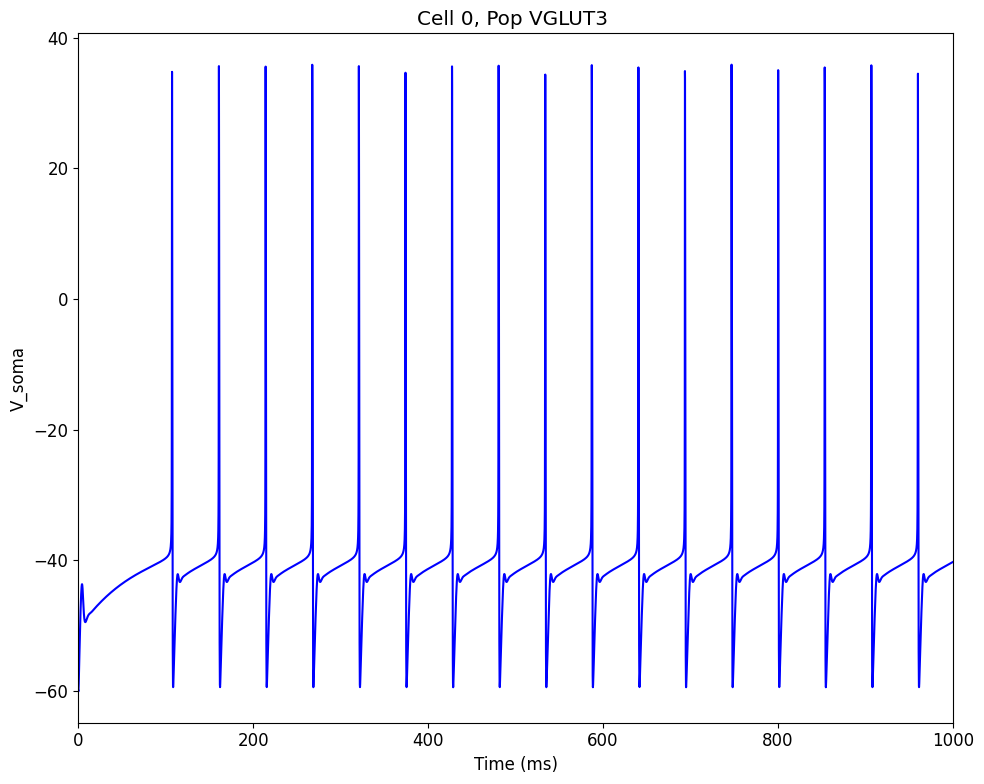

In [69]:
# makes dictionary of traits for VGLUT
EXdelayedRule  = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'dend': {'geom': {'L': 400.0, 'nseg': 5, 'diam': 3.0, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 2.0, 'depth': 0.1},
                             'HH2': {'gnabar': 0.0, 'gkbar': 0.144, 'vtraub': -50.2},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'borgka': {'gkabar': 0.0009333},
                             'KDRI': {'gkbar': 0.96e-05},
                             'pas': {'g': 0.96e-06, 'e': -65.0}},
                   'topol': {'parentSec': 'soma', 'parentX': 0.0, 'childX': 0.0}},
          'hillock': {'geom': {'L': 9.0, 'nseg': 3, 'diam': 1.5, 'Ra': 150.0, 'cm': 1.0},
                      'ions': {'k': {'e': -77.0, 'i': 54.4, 'o': 2.5},
                               'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                      'mechs': {'B_Na': {'gnabar': 0.03, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                                'HH2': {'gkbar': 0.304, 'gnabar': 0.02375, 'vtraub': -50.2},
                                'borgka': {'gkabar': 0.1120 * 1.0 },
                                'KDRI': {'gkbar': 0.01547},
                                'pas': {'g': 0.96e-06, 'e': -65.0}},
                      'topol': {'parentSec': 'soma', 'parentX': 1.0, 'childX': 0.0}},
          'soma': {'geom': {'L': 20.0, 'nseg': 3, 'diam': 20.0, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'B_Na': {'gnabar': 0.0001652, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                             'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 1.0, 'depth': 0.1},
                             'HH2': {'gkbar': 0.0043, 'gnabar': 0.08548, 'vtraub': -50.2},
                             'borgka': {'gkabar': 0.01090 * 1.0 },
                             'KDRI': {'gkbar': 0.0001110},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'pas': {'g': 0.96e-06, 'e': -65.0}},
                   'topol': {}}}
}

vglut_create_graph(EXdelayedRule, window = [0,1000], amp = 0.4, dur = 2000, sec_input = 'dend', title = "original 3-compartment model")


In [33]:
from ipywidgets import interact, FloatSlider
from IPython.display import display

def run_simulation_with_amp(amplitude):
    print(f"Running simulation with amplitude: {amplitude} nA")
    plot_title = f"3 compartment Simulation Trace (Amplitude: {amplitude} nA)"
    vglut_create_graph(EXdelayedRule, window = [0,1000], amp = amplitude, dur = 2000, sec_input = 'dend', title = "original 3 compartment model")

# Create a slider for the amplitude
amplitude_slider = FloatSlider(min=0.0, max=1.0, step=0.05, value=0.4, description='Amplitude (nA)')

# Use interact to link the slider to the function
interact(run_simulation_with_amp, amplitude=amplitude_slider);


interactive(children=(FloatSlider(value=0.4, description='Amplitude (nA)', max=1.0, step=0.05), Output()), _do…

In [3]:
print(sim.net.allCells[0]['tags'])              # confirm a cell exists at index 0
print(list(sim.simData.keys()))                 # are V_soma / V_dend / V_hillock present?
print(len(sim.simData['V_soma'].get('cell_0', []) if 'V_soma' in sim.simData else 'no V_soma'))
print(sim.net.cells[0].secs.keys())


{cellType: 'EXdl', pop: 'VGLUT3', xnorm: np.float64(0.3583531143706401), ynorm: np.float64(0.3984944342173416), znorm: np.float64(0.8763654583887277), x: np.float64(35.83531143706401), y: np.float64(39.84944342173416), z: np.float64(87.63654583887276), label: ['VGLUT3Rule']}
['spkt', 'spkid', 'V_soma', 't']
20001
dict_keys(['dend', 'hillock', 'soma'])


# **2.** **Simplifying to 1 compartment**

## 2a. delete hillock and dend without changing soma

result: constantly increasing voltage



Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|



*************************************************************
*************************************************************
The following graph depicts the initial 1 compartment model
*************************************************************
*************************************************************



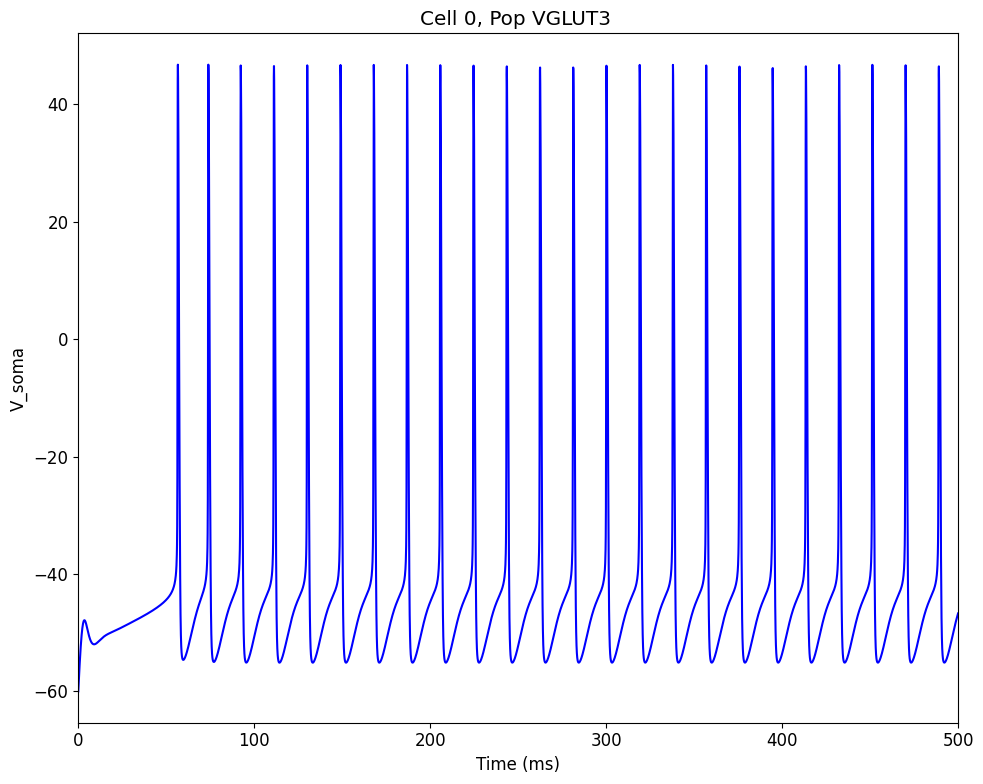

In [79]:
# makes dictionary of traits for VGLUT with only soma
#directly deletes dend and hillock without changing soa
EXdelayedRule1compa  = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'soma': {'geom': {'L': 20.0, 'nseg': 3, 'diam': 20.0, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'B_Na': {'gnabar': 0.0001652, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                             'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 1.0, 'depth': 0.1},
                             'HH2': {'gkbar': 0.0043, 'gnabar': 0.08548, 'vtraub': -50.2},
                             'borgka': {'gkabar': 0.01090 * 1.0 },
                             'KDRI': {'gkbar': 0.0001110},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'pas': {'g': 0.96e-06, 'e': -65.0}},
                   'topol': {}}}
}

vglut_create_graph(EXdelayedRule1compa, dur = 500, window = [0,500], amp = 0.1, title = "initial 1 compartment model")

## 2b. delete hillock and dend and change soma geometric properties




Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|



************************************************************
************************************************************
The following graph depicts the second 1 compartment model
************************************************************
************************************************************



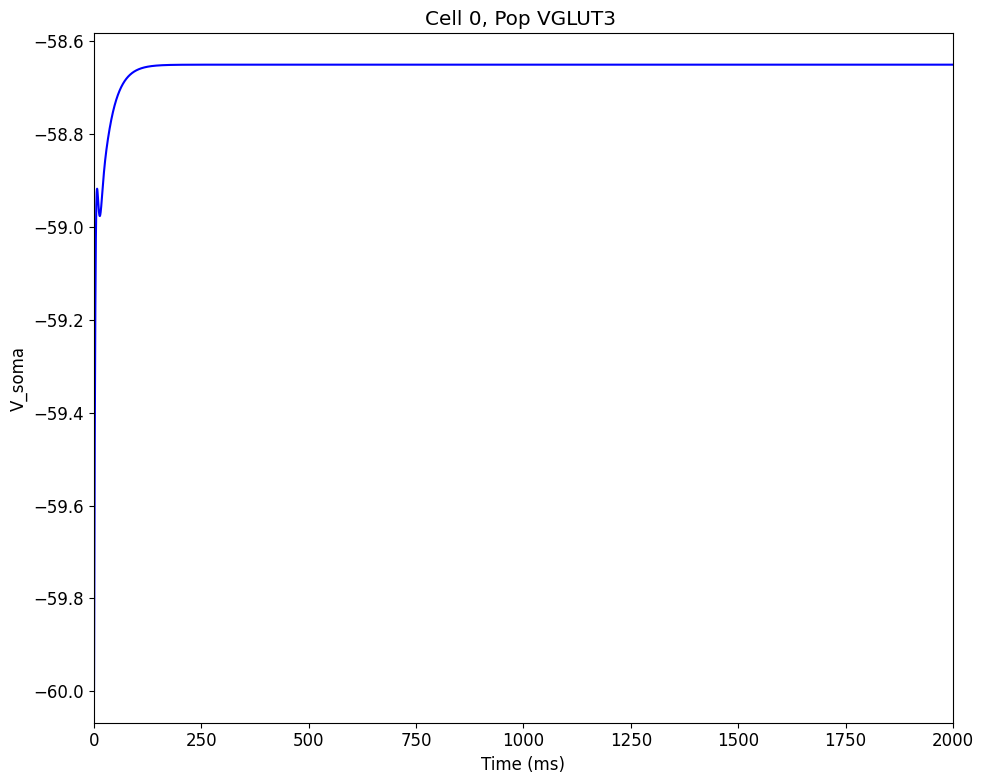

In [80]:
# makes dictionary of traits for VGLUT with only soma
#directly deletes dend and hillock without changing soa
EXdelayedRule1compb  = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'soma': {'geom': {'L': 80.6, 'nseg': 1, 'diam': 20, 'Ra': 150.0, 'cm': 1.0}, # L = 400 (d) + 9 (h) + 20 (s). diam = (3 + 1.5 + 20)/3 Ra (axial resistivity) = 150 (same for all) cm = 1 (same for all)
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'B_Na': {'gnabar': 0.0001652, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                             'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 1.0, 'depth': 0.1},
                             'HH2': {'gkbar': 0.0043, 'gnabar': 0.08548, 'vtraub': -50.2},
                             'borgka': {'gkabar': 0.01090 * 1.0 },
                             'KDRI': {'gkbar': 0.0001110},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'pas': {'g': 0.96e-06, 'e': -65.0}},
                   'topol': {}}}
}

vglut_create_graph(EXdelayedRule1compb, dur = 2000, window = [0,2000], amp = 0.1, title = "second 1 compartment model")

In [7]:
# code to calculate surface areas
from neuron import h
# surface area of soma
soma = h.Section(name='soma')
soma.L = 20        # Length in micrometers
soma.diam = 20     # Diameter in micrometers

# Calculate surface area at the center of the soma
# The argument 0.5 represents the normalized distance (0 to 1)
area_center_s = soma(0.5).area()
print(f"Soma surface area: {area_center_s} um2")

# surface area of dend
dend = h.Section(name='dend')
dend.L = 400        # Length in micrometers
dend.diam = 3     # Diameter in micrometers

# Calculate surface area at the center of the dend
area_center_d = dend(0.5).area()
print(f"Dendrites surface area: {area_center_d} um2")

# surface area of hillock
hill = h.Section(name='hillock')
hill.L = 9        # Length in micrometers
hill.diam = 1.5     # Diameter in micrometers

# Calculate surface area at the center of the hillock
area_center_h = hill(0.5).area()
print(f"Hillock surface area: {area_center_h} um2")

print(f"total are of soma, hillock, and dendrites: {area_center_h + area_center_d + area_center_s}")

# surface area of new soma:
new_soma = h.Section(name='new_soma')
new_soma.L = 80.6        # Length in micrometers
new_soma.diam = 20     # Diameter in micrometers
area_center = new_soma(0.5).area()
print(f"New soma surface area: {area_center} um2")

Soma surface area: 1256.6370614359173 um2
Dendrites surface area: 3769.9111843077517 um2
Hillock surface area: 42.411500823462205 um2
total are of soma, hillock, and dendrites: 5068.959746567131
New soma surface area: 5064.247357586746 um2


## 2c. change geometry and conductances of soma




Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|



***********************************************************
***********************************************************
The following graph depicts the third 1 compartment model
***********************************************************
***********************************************************



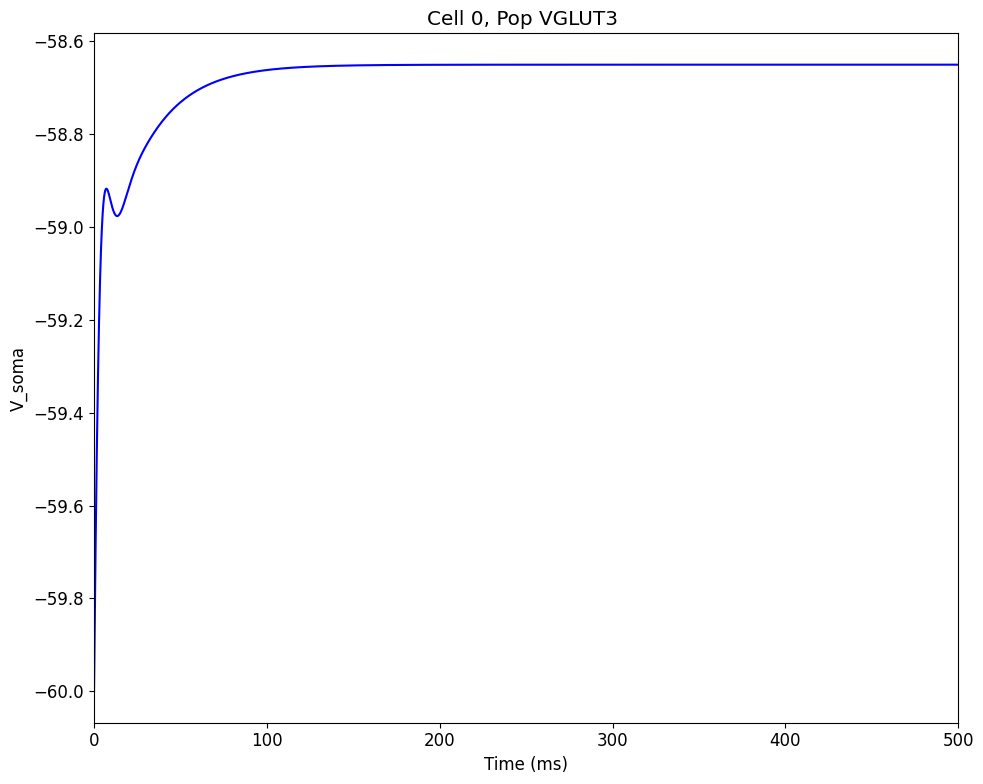

In [83]:
# makes dictionary of traits for VGLUT with only soma
#directly deletes dend and hillock without changing soa
EXdelayedRule1compc  = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'soma': {'geom': {'L': 80.6, 'nseg': 1, 'diam': 20, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'B_Na': {'gnabar': 0.0001652, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                             'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 1.0, 'depth': 0.1},
                             'HH2': {'gkbar': 0.043, 'gnabar': 0.08548, 'vtraub': -50.2},
                             'borgka': {'gkabar': 0.0109 * 1.0 },
                             'KDRI': {'gkbar': 0.000111},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'pas': {'g': 0.96e-6, 'e': -65.0}},
                   'topol': {}}}
}

vglut_create_graph(EXdelayedRule1compc, dur = 500, window = [0,500], amp = 0.1, title = "third 1 compartment model")

# New single compartment model attempt -> not from paper



Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|



***********************************************************************
***********************************************************************
The following graph depicts the hodkin-huxley ish 1 compartment model
***********************************************************************
***********************************************************************



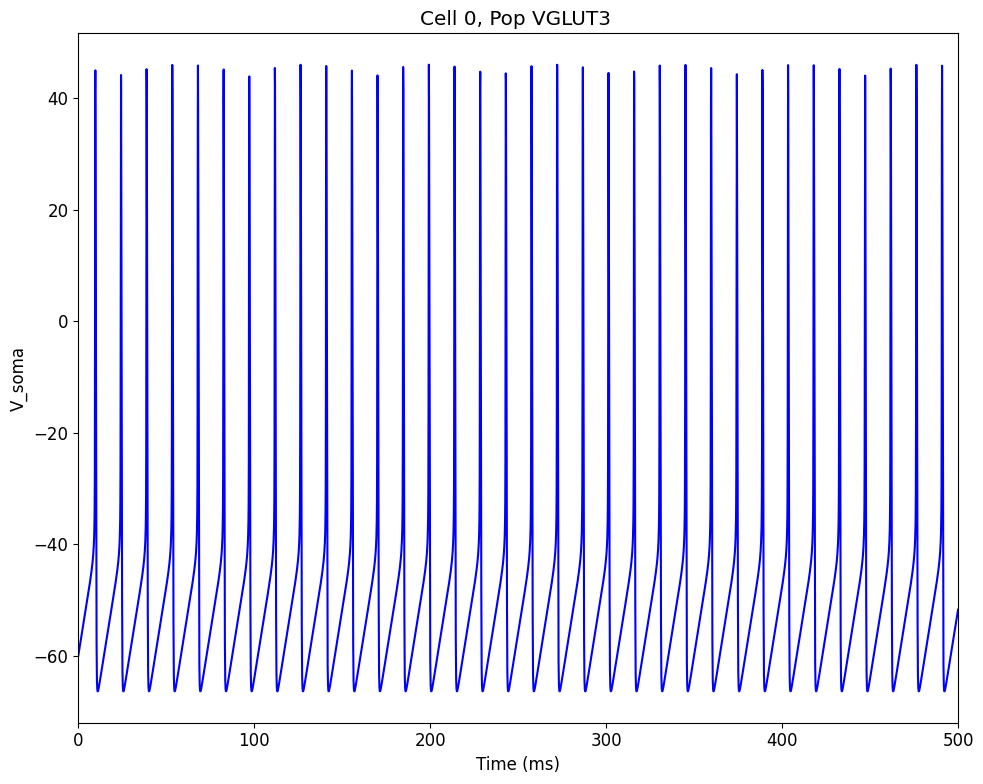

In [85]:
# makes dictionary of traits for VGLUT with only soma
#directly deletes dend and hillock without changing soa
Rule1comp  = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'soma': {'geom': {'L': 80.6, 'nseg': 1, 'diam': 20, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'HH2': {'gkbar': 0.043, 'gnabar': 0.08548, 'vtraub': -50.2},
                             'pas': {'g': 0.96e-6, 'e': -65.0}},
                   'topol': {}}}
}

vglut_create_graph(Rule1comp, dur = 500, window = [0,500], amp = 0.1, title = "hodkin-huxley ish 1 compartment model")
